In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import sklearn as sk

In [2]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [3]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [4]:
df.shape

(19402, 4)

In [5]:
Mexico = df[df["entity"] == "Mexico"]
print(Mexico)

       entity code  year  fertility_rate_hist
11125  Mexico  MEX  1950                6.709
11126  Mexico  MEX  1951                6.727
11127  Mexico  MEX  1952                6.731
11128  Mexico  MEX  1953                6.734
11129  Mexico  MEX  1954                6.745
...       ...  ...   ...                  ...
11194  Mexico  MEX  2019                2.020
11195  Mexico  MEX  2020                1.990
11196  Mexico  MEX  2021                1.970
11197  Mexico  MEX  2022                1.940
11198  Mexico  MEX  2023                1.910

[74 rows x 4 columns]


In [6]:
Japan = df[df["entity"] == "Japan"]
print(Japan)

     entity code  year  fertility_rate_hist
8384  Japan  JPN  1947                4.614
8385  Japan  JPN  1948                4.463
8386  Japan  JPN  1949                4.373
8387  Japan  JPN  1950                3.615
8388  Japan  JPN  1951                3.225
...     ...  ...   ...                  ...
8456  Japan  JPN  2019                1.323
8457  Japan  JPN  2020                1.304
8458  Japan  JPN  2021                1.275
8459  Japan  JPN  2022                1.256
8460  Japan  JPN  2023                1.208

[77 rows x 4 columns]


In [7]:
anios_mexico = Mexico["year"].to_numpy()
tasa_mexico = Mexico["fertility_rate_hist"].to_numpy()

anios_japon = Japan["year"].to_numpy()
tasa_japon = Japan["fertility_rate_hist"].to_numpy()


In [8]:
promedio_mexico = np.mean(tasa_mexico)
std_mexico = np.std(tasa_mexico)
min_mexico = np.min(tasa_mexico)
max_mexico = np.max(tasa_mexico)
promedio_japon = np.mean(tasa_japon)
std_japon = np.std(tasa_japon)
min_japon = np.min(tasa_japon)
max_japon = np.max(tasa_japon)


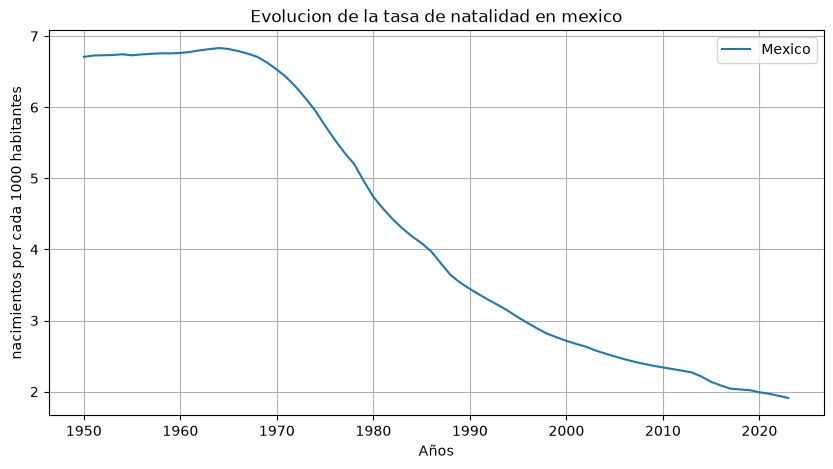

In [9]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.title("Evolucion de la tasa de natalidad en mexico")
plt.xlabel("Años")
plt.ylabel("nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

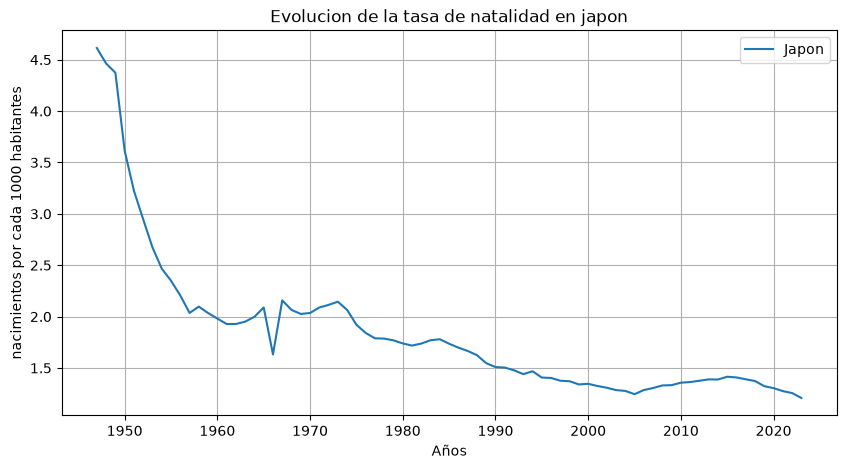

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japon"
)

plt.title("Evolucion de la tasa de natalidad en japon")
plt.xlabel("Años")
plt.ylabel("nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

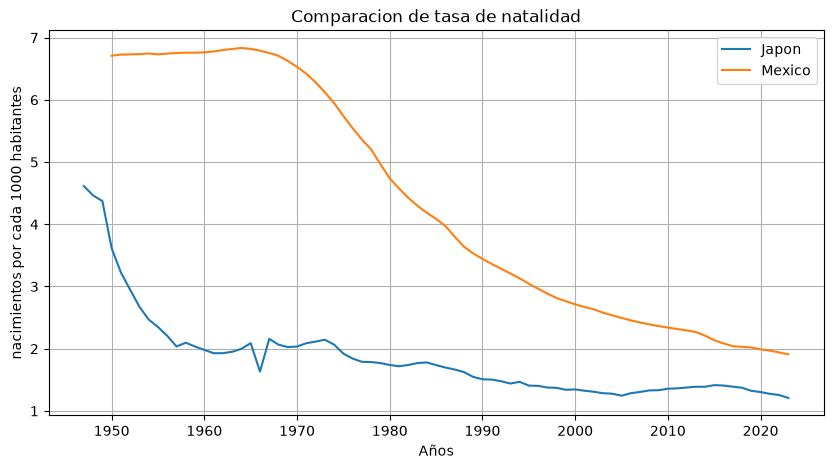

In [12]:


plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japon"
)

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.title("Comparacion de tasa de natalidad")
plt.xlabel("Años")
plt.ylabel("nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()


In [19]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
print(mascara_coincidencia_anios)

[False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


In [20]:
anios_japon = anios_japon[mascara_coincidencia_anios]

In [22]:
mascara_coincidencia_anios.shape

(77,)

In [21]:
anios_japon.shape

(74,)

In [29]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [31]:
diferencia_mx_jp = tasa_mexico - tasa_japon

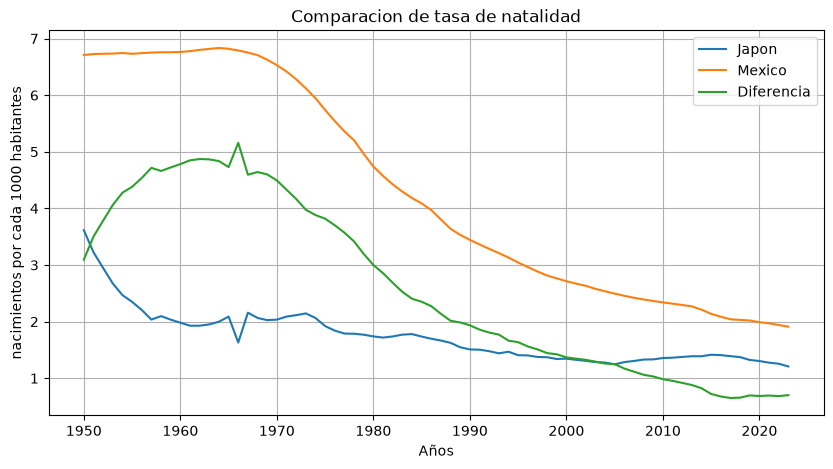

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japon"
)

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label="Diferencia"
)

plt.title("Comparacion de tasa de natalidad")
plt.xlabel("Años")
plt.ylabel("nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()


In [41]:
Brazil = df[df["entity"] == "Brazil"]
print(Brazil)

      entity code  year  fertility_rate_hist
2371  Brazil  BRA  1950                6.122
2372  Brazil  BRA  1951                6.115
2373  Brazil  BRA  1952                6.102
2374  Brazil  BRA  1953                6.093
2375  Brazil  BRA  1954                6.087
...      ...  ...   ...                  ...
2440  Brazil  BRA  2019                1.705
2441  Brazil  BRA  2020                1.653
2442  Brazil  BRA  2021                1.638
2443  Brazil  BRA  2022                1.629
2444  Brazil  BRA  2023                1.619

[74 rows x 4 columns]


In [ ]:
anios_brazil = Brazil["year"].to_numpy()
tasa_brazil =Brazil["fertility_rate_hist"].to_numpy()

In [43]:
Brazil.shape

(74, 4)

In [44]:
promedio_brazil= np.mean(tasa_brazil)
std_brazil = np.std(tasa_brazil)
min_brazil= np.min(tasa_brazil)
max_brazil = np.max(tasa_brazil)

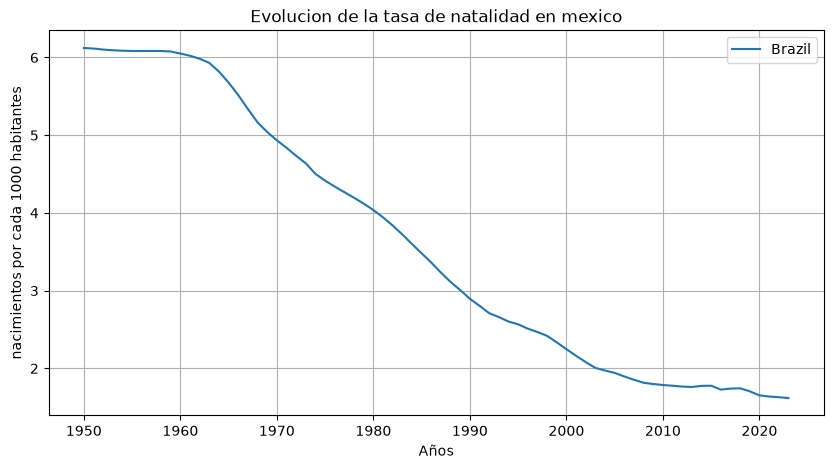

In [45]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_brazil,
    tasa_brazil,
    label="Brazil"
)

plt.title("Evolucion de la tasa de natalidad en mexico")
plt.xlabel("Años")
plt.ylabel("nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

In [47]:
diferencia_mx_brz = tasa_mexico - tasa_brazil

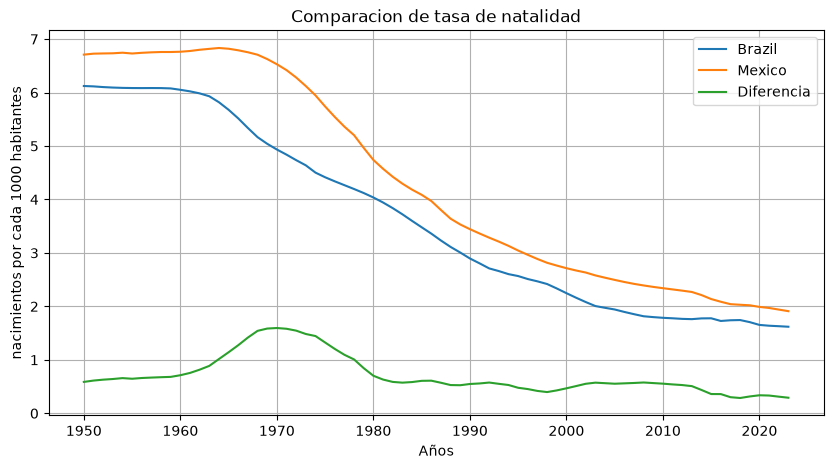

In [48]:

plt.figure(figsize=(10,5))
plt.plot(
    anios_brazil,
    tasa_brazil,
    label="Brazil"
)

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot(
    anios_mexico,
    diferencia_mx_brz,
    label="Diferencia"
)

plt.title("Comparacion de tasa de natalidad")
plt.xlabel("Años")
plt.ylabel("nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

In [56]:
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [57]:
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

### Otra froma de extraer datos es prepararlos desde otra funcion de pandas

In [62]:
comparacion_mexico_japon = pd.merge(
    Mexico[["year", "fertility_rate_hist"]],
    Japan[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)